### This is the script to do normal NLP analysis for climate risk disclosure

Notice: You should only run this after running '1-explatorary_analysis.ipynb'. And this one only use nltk the normal NLP analysis type

In [ ]:
#!pip install nltk
#!pip install PyPDF2

In [47]:
import ast, re, time, os, requests
import pandas as pd
import numpy as np
from datetime import date
import seaborn as sns 
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import textwrap
#NLTK Imports
import nltk 
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import PyPDF2
np.NaN = np.nan

nltk.download('vader_lexicon')
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Quyen\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Quyen\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [33]:
# Output folder for CSVs and PDFs — update if running on a different machine
FOLDER     = r'C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure'
FIG_FOLDER =  r'C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\5-Analysis2026'  
PDF_FOLDER = os.path.join(FOLDER, 'pdfs_2026','pdfs')


### First, explode the file into multipel pdf file

In [27]:
disclose_2026 = pd.read_csv(os.path.join(FIG_FOLDER, 'List_of_all_disclosures_as_of_2026_mapped.csv'))
#Explore 
disclose_2026['pdf_files'] = disclose_2026['pdf_files'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) else x
)

disclose_2026_exploded = (
    disclose_2026
    .explode('pdf_files')
    .dropna(subset=['pdf_files'])
    .reset_index(drop=True)
)


print(f'The number of disclosure is {disclose_2026.shape[0]}')
print(f'The number of disclosed PDF is {disclose_2026_exploded.shape[0]}')
#Then remove those without file
disclose_2026_exploded =disclose_2026_exploded[(disclose_2026_exploded['pdf_count']>0) ]
print(f'The number of disclosed PDF after remove those with 0 is {disclose_2026_exploded.shape[0]}')
# Then remove those with investment schemes 
disclose_2026_exploded = disclose_2026_exploded[disclose_2026_exploded['Type']!='Investment schemes']
print(f'The number of disclosed PDF for normal firms is {disclose_2026_exploded.shape[0]}')
# Then remove those in 2026 cohort 
disclose_2026_exploded = disclose_2026_exploded[disclose_2026_exploded['Cohort']!='Cohort 3 (Jul 2025 – Jun 2026)']
print(f'The number of disclosed PDF for normal firms in 2024-2025 is {disclose_2026_exploded.shape[0]}')
disclose_2026_exploded.to_csv(os.path.join(FIG_FOLDER, 'List_of_all_PDF_for_normal_companies.csv'))


The number of disclosure is 743
The number of disclosed PDF is 3206
The number of disclosed PDF after remove those with 0 is 3206
The number of disclosed PDF for normal firms is 410
The number of disclosed PDF for normal firms in 2024-2025 is 360


In [18]:
disclose_2026_exploded.groupby(['Cohort', 'Status']).size()

Cohort                          Status               
Cohort 1 (≤ Jun 2024)           Submitted                149
Cohort 2 (Jul 2024 – Jun 2025)  Not required to lodge     19
                                Submitted                192
dtype: int64

### Now, let us define functions to run the NLP analysis 

In [29]:
#sentiment
sent = SentimentIntensityAnalyzer()
st = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))


## climate hazard datasets key words
drought = ['drought', 'severe drought', 'dry', 'SPI', 'standardised precipitation index', 'standardized precipitation index', 'rainfall', '10 minute average', 'topography']
winds= ['wind', 'extreme winds', 'cyclone','tsunami']
rainfall =['rain','pluvial','pluvial flooding','rainfall']
river = ['river','flood', 'river flooding', 'fluvial',
         'daily rainfall', 'river level', 'flow', 'soils', 'vegetation', 
        ]
coastal = ['coastal','flood','topography',  'sea-level', 'sea level', 'esl', 'extreme sea',
           'coastal flooding', 'inundation', 'groundwater','nearshore', 'bathymetry', 'bathymetric']
shoreline_change = ['shoreline change','aerial', 'aerial photography', 'historical aerial', 'topography', 'soils', 'soil', 'geology']
heatwave = ['heatwave', 'extreme temperature', 'humidity', 'rainfall', 'extreme heat', 'heat']
landslide =['landslide', 'soil', ' soil erosion', 'erosion', 'topography', 'geology', 'soils', 'vegetation', 'rainfall']
other = ['extreme event', 'extreme heat','extreme sea','extreme winds', 'disaster']
emissions = ['emission', 'carbon', 'ghg','greenhouse','methane',' ets ']
gns_related_words = [' gns', 'merit', 'riskscape','nigem','nz searise', 'groundwater', 'antarctica']
niwa_words = [' niwa']
## put climate hazards into a list to easily loop over
keywords= drought +  winds +  river +  coastal +  shoreline_change +  heatwave +  landslide + other + emissions + other +gns_related_words +niwa_words

In [30]:
# A function to get page text 
def get_pages_text(file_name):
    pages_text = {}
    with open(file_name, 'rb') as pdfFileObject:
        pdfReader = PyPDF2.PdfReader(pdfFileObject)

        print("No. of Pages:", len(pdfReader.pages))
        for i, page in enumerate(pdfReader.pages):
            pages_text[i] = page.extract_text()
    return pages_text 

# Clean data 
def clean_data(text):
    # change to lower and remove spaces on either side
    text =  text.lower().strip() 

    # remove extra spaces in between
    text = re.sub(' +', ' ', text)

    # remove punctuation
    text= re.sub('[^a-zA-Z]', ' ', text)

    # remove stopwords and get the stem
    text =  ' '.join(st.stem(x) for x in text.split() if x not in stop_words)
    return text

In [68]:
disclose_2026_exploded['Cohort'].unique()

array(['Cohort 2 (Jul 2024 – Jun 2025)', 'Cohort 1 (≤ Jun 2024)'],
      dtype=object)

In [72]:
#Simple analysis 
nlp_analysis = pd.DataFrame()
for i,row  in disclose_2026_exploded.iterrows():
    pdf_file = row['pdf_files']
    company = row['Company Name']
    period_year = row['period_year']
    period = row['PeriodDate']
    industry = row['Industry']
    cohort = row['Cohort']
    #Get safe name 
    safe_name = re.sub(r'[^\w\s-]', '', company)[:50].strip().replace(' ', '_') + f"_{period_year}"
    company_folder = os.path.join(PDF_FOLDER, safe_name)
    pdfs = glob.glob(os.path.join(company_folder, '*.pdf'))
    filename = os.path.join(PDF_FOLDER, safe_name,pdf_file)

    print(filename)
    try: 
        pages_text = get_pages_text(filename).values()
        pages_text_final = ' '.join(pages_text)
        #clean data 
        page_text_clean = clean_data(pages_text_final)

        #sentiment analysis 
        polarity = sent.polarity_scores(page_text_clean)

        # Count the number of digits
        digits = re.findall(r'\d', pages_text_final)
        dollars = re.findall(r'\$|NZD', pages_text_final)
        percentages = re.findall(r'\%', pages_text_final)

        num_digits = len(digits)
        num_dollars = len(dollars)
        num_percentages = len(percentages)


        #row info 
        row = {'file_name': pdf_file,
               'company_name': company,
               'period_year' :period_year,
               'period_date':period,
               'industry':industry,
               'cohort':cohort,
               'pages_num' : len(pages_text),
               'number_characters' : len(pages_text_final),
               'number_words' : len(pages_text_final.split(' ')),
               'negative': polarity['neg'],
               'neutral': polarity['neu'],
               'positive': polarity['pos'], 
               'compound': polarity['compound'],
               'readable': 'Readable',
               'digits': num_digits,
               'dollars': num_dollars,
               'percentages': num_percentages
              }

        # Count the number of keywords 
        for keyword in keywords:
            row[keyword] = len(re.findall(keyword, page_text_clean))
        # Append the row to the DataFrame
        # Using ignore_index=True to ensure that indexes are handled correctly
        # Convert the dictionary to a DataFrame and specify it should be a single row
        row_df = pd.DataFrame([row])  # Note the [row] to convert the single dictionary to a DataFrame
        nlp_analysis = pd.concat([nlp_analysis, row_df], ignore_index=True)
    except: 
        print('error')
        #row info 
        row = {'file_name': pdf_file,
               'company_name': company,
               'period_year' :period_year,
               'period_date':period,
               'industry':industry,
               'cohort':cohort,
               'pages_num' :np.nan,
               'number_characters' : np.nan,
               'number_words' :np.nan,
               'negative': np.nan,
               'neutral': np.nan,
               'positive': np.nan, 
               'compound':np.nan,
               'readable': 'UnReadable',
               'digits': np.nan,
               'dollars': np.nan,
               'percentages': np.nan
              }

        # Count the number of keywords 
        for keyword in keywords:
            row[keyword] = np.NaN
        # Convert the dictionary to a DataFrame and specify it should be a single row
        row_df = pd.DataFrame([row])  # Note the [row] to convert the single dictionary to a DataFrame
        nlp_analysis = pd.concat([nlp_analysis, row_df], ignore_index=True)
nlp_analysis.to_csv( os.path.join(FIG_FOLDER, 'Table01_nlp_analysis_submitted_normal_firms_2024_2025.csv'))    

C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AA_INSURANCE_LIMITED_2025\AA Insurance 2025 Climate Statement FINAL SIGNED.pdf
No. of Pages: 34
C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AA_INSURANCE_LIMITED_2025\GHG assurance report FY25 SIGNED.pdf
No. of Pages: 5
C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AA_INSURANCE_LIMITED_2024\AA Insurance 2024 Climate Statements.pdf
No. of Pages: 23
C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AFT_PHARMACEUTICALS_LIMITED_2024\240523 FY2024 Annual Report.pdf
No. of Pages: 126
C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AFT_PHARMACEUTICALS_LIMITED_2024\FY2024 Annual Report also

In [ ]:
from scipy import stats

metrics      = ['pages_num', 'number_words', 'compound', 'digits', 'dollars', 'percentages']
cohort_names = sorted(nlp_analysis['cohort'].unique())
c1_name      = cohort_names[0]  # Cohort 1 (≤ Jun 2024)
c2_name      = cohort_names[1]  # Cohort 2 (Jul 2024 – Jun 2025)
print(c1_name, '|', c2_name)

# ── T-tests ────────────────────────────────────────────────────────────────────
ttest_results = []
for industry, grp in nlp_analysis.groupby('industry'):
    for metric in metrics:
        g1 = grp[grp['cohort'] == c1_name][metric].dropna()
        g2 = grp[grp['cohort'] == c2_name][metric].dropna()
        if len(g1) > 1 and len(g2) > 1:
            t, p = stats.ttest_ind(g1, g2)
            ttest_results.append({
                'industry': industry, 'metric': metric,
                't_stat': round(t, 3), 'p_value': round(p, 4),
                'sig': '*' if p < 0.05 else '',
            })

ttest_df = pd.DataFrame(ttest_results)

# ── Summary table ──────────────────────────────────────────────────────────────
summary = nlp_analysis.groupby(['industry', 'cohort'])[metrics].mean().round(2)
summary.columns = [f'{c}_mean' for c in summary.columns]
summary = summary.reset_index()

c1 = summary[summary['cohort'] == c1_name].set_index('industry').drop(columns='cohort')
c2 = summary[summary['cohort'] == c2_name].set_index('industry').drop(columns='cohort')
comparison = c1.join(c2, lsuffix='_C1', rsuffix='_C2')

# ── Add sig stars ──────────────────────────────────────────────────────────────
for metric in metrics:
    pvalue_lookup = ttest_df[ttest_df['metric'] == metric].set_index('industry')['p_value']  
    comparison[f'{metric}_pvalue'] = comparison.index.map(pvalue_lookup).fillna('')

comparison.to_csv(os.path.join(FIG_FOLDER, 'Table03_cohort1_vs_cohort2.csv'))
comparison
summary.to_csv( os.path.join(FIG_FOLDER, 'Table02_comparing_nlp_analysis_between_2024_2025.csv'))    


Cohort 1 (≤ Jun 2024) | Cohort 2 (Jul 2024 – Jun 2025)


,pages_num_mean_C1,number_words_mean_C1,compound_mean_C1,digits_mean_C1,dollars_mean_C1,percentages_mean_C1,pages_num_mean_C2,number_words_mean_C2,compound_mean_C2,digits_mean_C2,dollars_mean_C2,percentages_mean_C2,pages_num_pvalue,number_words_pvalue,compound_pvalue,digits_pvalue,dollars_pvalue,percentages_pvalue
industry,,,,,,,,,,,,,,,,,,
Agriculture,28.00,11920.70,0.15,1533.70,10.00,51.50,47.29,19733.71,0.53,3510.21,60.07,118.50,0.2307,0.2626,0.3163,0.2826,0.3914,0.2923
Airport,29.00,14825.40,-0.21,2067.20,13.80,37.00,28.83,15702.50,0.64,2149.33,11.50,39.00,0.9872,0.87,0.166,0.8983,0.7424,0.8948
Constructions,19.14,7167.71,0.12,884.00,7.43,28.14,35.17,15150.50,-0.35,1990.50,23.17,92.33,0.218,0.1327,0.4326,0.1521,0.2023,0.2224
Energy,42.75,21083.12,0.73,2922.75,31.75,59.62,49.00,22659.25,0.77,3182.62,36.75,73.88,0.59,0.7687,0.9083,0.7894,0.6815,0.6556
Finance - Banks,27.21,10146.43,-0.34,1058.07,10.36,41.36,27.07,11619.30,0.06,1496.77,23.10,57.57,0.9865,0.7171,0.1674,0.4515,0.1872,0.5242
Finance - Insurance,19.56,7420.38,-0.39,730.56,5.88,19.25,36.86,14534.45,-0.19,2459.14,29.36,50.64,0.0545,0.0559,0.5195,0.0571,0.1276,0.192
Finance - Other,37.00,11733.14,0.60,2618.64,50.07,57.57,32.31,12197.50,0.40,2306.19,37.88,72.31,0.7854,0.9421,0.4345,0.8692,0.8128,0.76
Healthcare,55.25,20086.50,0.02,4665.00,102.75,147.25,64.50,24977.50,0.00,5077.75,96.25,156.25,0.8737,0.8196,0.9851,0.9447,0.9627,0.9588
Infrastructure,70.88,25975.25,0.47,5233.50,55.75,109.75,47.84,20335.11,0.69,4001.21,71.79,128.79,0.4024,0.5703,0.4679,0.6422,0.7922,0.8223


,industry,metric,cohort_a,cohort_b,t_stat,p_value,sig
0,Agriculture,pages_num,Cohort 2 (Jul 2024 – Jun 2025),Cohort 1 (≤ Jun 2024),1.137,0.2678,
1,Agriculture,number_words,Cohort 2 (Jul 2024 – Jun 2025),Cohort 1 (≤ Jun 2024),1.150,0.2626,
2,Agriculture,compound,Cohort 2 (Jul 2024 – Jun 2025),Cohort 1 (≤ Jun 2024),1.026,0.3163,
3,Agriculture,digits,Cohort 2 (Jul 2024 – Jun 2025),Cohort 1 (≤ Jun 2024),1.101,0.2826,
4,Agriculture,dollars,Cohort 2 (Jul 2024 – Jun 2025),Cohort 1 (≤ Jun 2024),0.874,0.3914,
...,...,...,...,...,...,...,...
73,Telecom,number_words,Cohort 2 (Jul 2024 – Jun 2025),Cohort 1 (≤ Jun 2024),-0.429,0.6745,
74,Telecom,compound,Cohort 2 (Jul 2024 – Jun 2025),Cohort 1 (≤ Jun 2024),0.506,0.6206,
75,Telecom,digits,Cohort 2 (Jul 2024 – Jun 2025),Cohort 1 (≤ Jun 2024),-0.468,0.6472,
76,Telecom,dollars,Cohort 2 (Jul 2024 – Jun 2025),Cohort 1 (≤ Jun 2024),-0.845,0.4122,


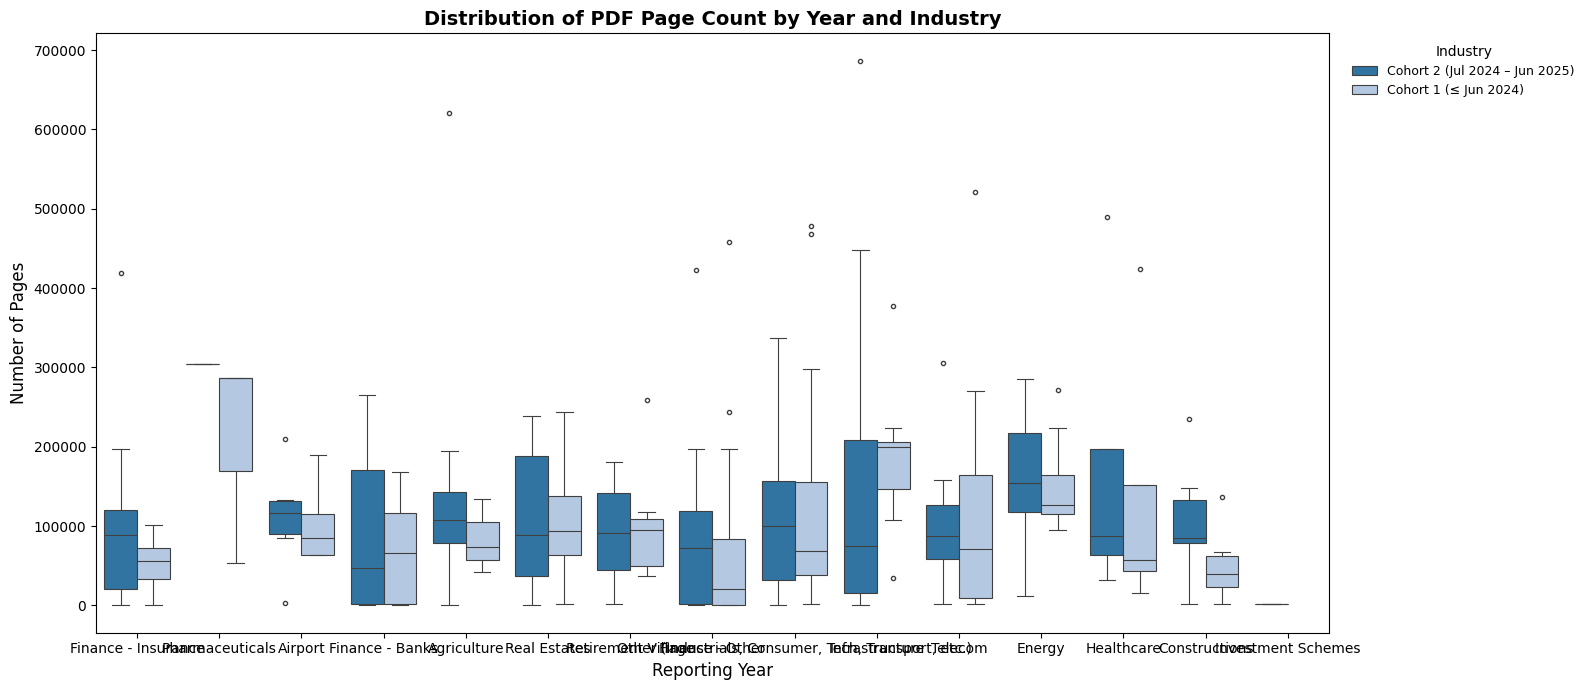

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 7))

sns.boxplot(
    data=nlp_analysis,
    x='industry',
    y='pages_num',
    hue='cohort',
    palette='tab20',
    linewidth=0.8,
    fliersize=3,
    ax=ax
)

ax.set_title('Distribution of PDF Page Count by Year and Industry', fontweight='bold', fontsize=14)
ax.set_xlabel('Reporting Year', fontsize=12)
ax.set_ylabel('Number of Pages', fontsize=12)
ax.legend(title='Industry', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FOLDER, 'pdfs_2026', 'pages_boxplot_industry_year.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
